# AutoGrow Analytics Notebook
## Complex Data Project: Growth Stage Analysis
### Advanced Analytics Pipeline: Isolation Forest → XGBoost + TimeSeriesSplit → SHAP

> **Three-Stage Intelligence Pipeline (Beyond Course)**
> 1. **Stage 1 (Isolation Forest):** Multivariate IoT anomaly detection before modelling
> 2. **Stage 2 (XGBoost + TimeSeriesSplit):** Gradient boosting with temporal cross-validation
> 3. **Stage 3 (SHAP):** Feature interpretability — *why* the model predicts each growth stage


## 1) Setup and Load 3 Tables
### 1.1 Install/Import Requirements
**Goal:** Ensure the notebook can run in the current kernel.

**What we do:** Auto-install missing packages, then import libraries.

**Method:** `importlib` for check and `pip install` for fallback.


In [1]:
# Standard library imports
import importlib       
import subprocess      
import sys            
import os             
from urllib.parse import quote_plus 


# Auto-installer function 
def ensure_package(pip_name, import_name=None):
    """
    Tries to import a package. If it's not found, installs it automatically via pip.
    
    - pip_name:    the name used when installing  (e.g. 'scikit-learn')
    - import_name: the name used when importing   (e.g. 'sklearn')
                   These differ for some packages, so we handle both.
    """
    module = import_name or pip_name  # Fall back to pip_name if no import_name given
    try:
        importlib.import_module(module)        # Try importing the package
    except ModuleNotFoundError:
        print(f"Installing missing package: {pip_name}")
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pip_name])


# Auto-install all required packages if not already present 
ensure_package('numpy')                      
ensure_package('pandas')                      
ensure_package('matplotlib')                 
ensure_package('seaborn')                    
ensure_package('scikit-learn', 'sklearn')     
ensure_package('xgboost', 'xgboost')          
ensure_package('shap', 'shap')               
ensure_package('PyMySQL', 'pymysql')          
ensure_package('sqlalchemy', 'sqlalchemy')    
ensure_package('imbalanced-learn', 'imblearn') 


# Core data & plotting imports
import numpy as np                
import pandas as pd               
import matplotlib.pyplot as plt  
import seaborn as sns            
import pymysql                   


# Scikit-learn: evaluation metrics 
from sklearn.metrics import (
    f1_score,               
    classification_report,  
    confusion_matrix,     
    mean_absolute_error,   
    mean_squared_error,     
)

# Scikit-learn: pipeline & preprocessing 
from sklearn.pipeline import Pipeline          
from sklearn.impute import SimpleImputer       
from sklearn.preprocessing import StandardScaler  

# Scikit-learn: models 
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.ensemble import RandomForestClassifier, IsolationForest

# Scikit-learn: model selection 
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.preprocessing import LabelEncoder  
from sklearn.linear_model import LinearRegression 


# Additional plotting utilities
import matplotlib.dates as mdates  
import matplotlib.patches as mpatches 


# Advanced ML libraries 
import xgboost as xgb  
import shap           


# Global display settings 
sns.set_theme(style='whitegrid')           # Applies a clean white background to all seaborn plots
pd.set_option('display.max_columns', 200)  # Prevents pandas from hiding columns in wide DataFrames

print('Imports ready')  

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Imports ready


### 1.2 Connect DB and Load Tables
**Goal:** Load all required sources into 3 DataFrames.

**What we do:** Connect to MySQL and query 3 tables.

**Method:** `SHOW TABLES` + case-insensitive table matching + `pd.read_sql`.


In [2]:
from sqlalchemy import create_engine, text

# os.getenv() reads from environment variables, falling back to the hardcoded
# default if not set — keeps credentials out of the code in production
DB_HOST = os.getenv('DB_HOST', 'iot.cpe.ku.ac.th')
DB_USER = os.getenv('DB_USER', 'b6710545652')
DB_NAME = os.getenv('DB_NAME', 'b6710545652')
DB_PASS = os.getenv('DB_PASS', 'natcha.limsu@ku.th')

engine = create_engine(
    # quote_plus() encodes special characters in the password (e.g. '@' → '%40')
    # so the URL doesn't break when the password contains symbols
    f'mysql+pymysql://{DB_USER}:{quote_plus(DB_PASS)}@{DB_HOST}/{DB_NAME}?charset=utf8mb4'
)

with engine.connect() as conn:
    tables_df = pd.read_sql(text('SHOW TABLES'), conn)
    # SHOW TABLES returns a column named "Tables_in_<dbname>" which varies per DB,
    # so we grab whichever column it is dynamically instead of hardcoding the name
    table_col = tables_df.columns[0]
    all_tables = tables_df[table_col].astype(str).tolist()

def pick_table(name):
    low = {t.lower(): t for t in all_tables}
    if name.lower() in low:
        return low[name.lower()]
    # Partial match fallback — in case the actual table name has a prefix/suffix
    contains = [t for t in all_tables if name.lower() in t.lower()]
    if len(contains) == 1:
        return contains[0]
    raise ValueError(f'Cannot uniquely find table {name!r}. Available tables: {all_tables}')

autogrow_table = pick_table('Autogrow')
current_table  = pick_table('outdoor_weather_current')
history_table  = pick_table('outdoor_weather_history')

with engine.connect() as conn:
    df_autogrow                = pd.read_sql(text(f'SELECT * FROM `{autogrow_table}`'),  conn)
    df_outdoor_weather_current = pd.read_sql(text(f'SELECT * FROM `{current_table}`'),   conn)
    df_outdoor_weather_history = pd.read_sql(text(f'SELECT * FROM `{history_table}`'),   conn)

# Normalize column names so lookups are consistent regardless of how the DB named them
for _df in [df_autogrow, df_outdoor_weather_current, df_outdoor_weather_history]:
    _df.columns = [c.strip().lower() for c in _df.columns]

print('Loaded tables:')
print(f'- {autogrow_table}:', df_autogrow.shape)
print(f'- {current_table}:', df_outdoor_weather_current.shape)
print(f'- {history_table}:', df_outdoor_weather_history.shape)

Loaded tables:
- Autogrow: (1569, 16)
- outdoor_weather_current: (98, 12)
- outdoor_weather_history: (192, 7)


### 1.3 Preview
**Goal:** Confirm schemas before exploration.

**What we do:** View top rows from all 3 data sources.

**Method:** `.head()` display.


In [3]:
display(df_autogrow.head())
display(df_outdoor_weather_current.head())
display(df_outdoor_weather_history.head())

,id,ts,stage,stage_name,spectrum,temp1,temp2,humidity,soil_pct,light_lux,vibration,pump_on,pump_status,light_hrs_today,harvest_eta_days,health_score
0,2,2026-04-11 17:07:39,0,Seedling,OFF,31.0,31.0,92.0,100.0,250.3,0,0,IDLE,3.18,14,80
1,3,2026-04-11 17:17:40,0,Seedling,OFF,31.0,31.0,90.0,100.0,225.9,0,0,IDLE,3.34,14,80
2,4,2026-04-11 17:27:41,0,Seedling,OFF,31.0,31.0,89.5,99.9,214.7,0,0,IDLE,3.51,14,80
3,5,2026-03-31 03:02:57,0,Seedling,OFF,45.0,0.0,45.0,45.0,45.0,0,0,OK,0.00,0,0
4,6,2026-03-31 03:04:02,0,Seedling,OFF,45.0,0.0,45.0,50.0,45.0,0,0,OK,0.00,0,0


,id,lat,lon,source,temp_c,humidity,wind_speed_mps,apparent_temp_c,sunrise_utc,sunset_utc,fetched_at,stored_at
0,1,13.7563,100.502,open-meteo,29.0,82.0,10.1,34.7,2026-04-19 23:02:00,2026-04-20 11:31:00,2026-04-20 17:52:48,2026-04-20 19:04:18
1,2,13.7563,100.502,open-meteo,29.0,82.0,10.1,34.7,2026-04-19 23:02:00,2026-04-20 11:31:00,2026-04-20 17:52:48,2026-04-20 19:21:50
2,3,13.7563,100.502,open-meteo,28.8,81.0,8.6,34.5,2026-04-19 23:02:00,2026-04-20 11:31:00,2026-04-20 19:22:37,2026-04-20 19:22:37
3,4,13.7563,100.502,open-meteo,32.5,64.0,8.9,39.3,2026-04-21 06:01:00,2026-04-21 18:32:00,2026-04-21 04:16:54,2026-04-21 04:24:50
4,5,13.7563,100.502,open-meteo,32.5,64.0,8.9,39.3,2026-04-20 23:01:00,2026-04-21 11:32:00,2026-04-21 04:18:51,2026-04-21 04:24:50


,id,lat,lon,source,ts,temp_c,humidity
0,1,13.7563,100.502,open-meteo,2026-04-13 00:00:00,28.3,89.0
1,2,13.7563,100.502,open-meteo,2026-04-13 01:00:00,30.0,76.0
2,3,13.7563,100.502,open-meteo,2026-04-13 02:00:00,31.8,62.0
3,4,13.7563,100.502,open-meteo,2026-04-13 03:00:00,33.3,57.0
4,5,13.7563,100.502,open-meteo,2026-04-13 04:00:00,34.9,52.0


## 2) Complex Data Exploration
### 2.1 Detect Key Columns & Parse Timestamps
**Goal:** Standardize all three DataFrames so they share consistent column names and timestamps, ready for merging and modeling

**Method:** Heuristic column detection using priority name lists + pd.to_datetime for timestamp parsing.


**Processes:** 
- **Column detection**:  first_existing() returns the first matching candidate name found in the DataFrame, handling schema differences
- **Timestamp detection**:  detect_datetime_col() picks the column with the highest datetime parse success rate
- **Timestamp standardization**:  converts all timestamps to UTC then strips timezone info for consistent comparison
- **Hour bucketing**:  floors timestamps to the nearest hour, creating a shared merge key for indoor and outdoor data



In [4]:
def first_existing(columns, candidates):
    colset = set(columns)
    for c in candidates:
        if c in colset:
            return c
    return None  # Returns None if none of the candidates exist


def detect_datetime_col(df):
    # Filter columns whose names suggest they contain datetime values
    candidates = [c for c in df.columns if any(k in c for k in ['time', 'date', 'created', 'ts'])]
    best, score = None, -1
    for c in candidates:
        parsed = pd.to_datetime(df[c], errors='coerce', utc=True)
        # Score each candidate by what fraction of its values successfully parsed as datetime
        # The column with the highest success rate wins
        s = parsed.notna().mean()
        if s > score:
            best, score = c, s
    return best

ag = df_autogrow.copy()
wh = df_outdoor_weather_history.copy()
wc = df_outdoor_weather_current.copy()

col_ts_ag = detect_datetime_col(ag)
col_ts_wh = detect_datetime_col(wh)
col_ts_wc = detect_datetime_col(wc)

# first_existing() tries each candidate name in order and returns the first one found
# — handles different naming conventions across DB schemas
col_stage_name  = first_existing(ag.columns, ['stage_name'])
col_stage       = first_existing(ag.columns, ['stage'])
col_temp_in     = first_existing(ag.columns, ['temp1', 'temperature', 'temp'])
col_hum_in      = first_existing(ag.columns, ['humidity', 'humidity1', 'rh'])
col_soil        = first_existing(ag.columns, ['soil_pct', 'soil', 'soil_moisture'])
col_light_lux   = first_existing(ag.columns, ['light_lux', 'lux', 'light'])
col_light_hrs   = first_existing(ag.columns, ['light_hrs_today', 'light_hours_today', 'light_hrs'])
col_health      = first_existing(ag.columns, ['health_score', 'health'])
col_vibration   = first_existing(ag.columns, ['vibration'])
col_pump_status = first_existing(ag.columns, ['pump_status', 'pump_state', 'pump'])

col_temp_out = first_existing(wh.columns, ['temp_c', 'temperature_2m', 'temperature', 'temp'])
col_hum_out  = first_existing(wh.columns, ['humidity', 'relative_humidity_2m', 'humidity_2m'])

# Fixed names for outdoor features after merging — used consistently downstream
col_temp_out_feat = 'outdoor_temp'
col_hum_out_feat  = 'outdoor_humidity'

if col_ts_ag is None or col_ts_wh is None:
    raise ValueError('Cannot detect timestamp columns in Autogrow or outdoor_weather_history.')

# Parse timestamps: utc=True standardizes timezone, tz_localize(None) strips it
# so all three DataFrames use naive (timezone-free) datetimes for easy comparison
ag['ts'] = pd.to_datetime(ag[col_ts_ag], errors='coerce', utc=True).dt.tz_localize(None)
wh['ts'] = pd.to_datetime(wh[col_ts_wh], errors='coerce', utc=True).dt.tz_localize(None)
if col_ts_wc:
    wc['ts'] = pd.to_datetime(wc[col_ts_wc], errors='coerce', utc=True).dt.tz_localize(None)

ag = ag.dropna(subset=['ts']).sort_values('ts').reset_index(drop=True)
wh = wh.dropna(subset=['ts']).sort_values('ts').reset_index(drop=True)

# Floor timestamps to the nearest hour so indoor and outdoor data
# can be joined on a shared hourly key later in the pipeline
ag['hour_bucket'] = ag['ts'].dt.floor('h')
wh['hour_bucket'] = wh['ts'].dt.floor('h')

### 2.2 Column Detection Result
**Goal:** Verify that column detection and timestamp parsing worked correctly before proceeding.

**Method:** Plain print statements inspecting detected column names and data time ranges.

**Processes:** 
- **Column audit:** prints every detected sensor/target column so any None values (missed detections) are immediately visible
- **Time range check:** confirms the date coverage and row count of both indoor and outdoor datasets


In [5]:
# Sanity check — confirms which columns were auto-detected before any modeling begins
print('Detected columns summary:')
print('  - stage_name:', col_stage_name)
print('  - stage:', col_stage)
print('  - temp_in:', col_temp_in)
print('  - temp_out:', col_temp_out)
print('  - hum_in:', col_hum_in)
print('  - hum_out:', col_hum_out)
print('  - soil:', col_soil)
print('  - light:', col_light_lux)
print('  - health:', col_health)
print('  - vibration:', col_vibration)
print('  - pump_status:', col_pump_status)
print('  - Time range from indoor sensors (AutoGrow table):', ag['ts'].min(), '->', ag['ts'].max(), '| rows:', len(ag))
print('  - Time range from API (weather history table):', wh['ts'].min(), '->', wh['ts'].max(), '| rows:', len(wh))

Detected columns summary:
  - stage_name: stage_name
  - stage: stage
  - temp_in: temp1
  - temp_out: temp_c
  - hum_in: humidity
  - hum_out: humidity
  - soil: soil_pct
  - light: light_lux
  - health: health_score
  - vibration: vibration
  - pump_status: pump_status
  - Time range from indoor sensors (AutoGrow table): 2026-03-31 03:02:57 -> 2026-04-18 13:18:29 | rows: 1569
  - Time range from API (weather history table): 2026-04-13 00:00:00 -> 2026-04-20 23:00:00 | rows: 192


## 2.3 Time-Series Visualization

**Goal:**  Visualize how each indoor sensor reading changes over the full duration of the experiment.

**Method:** One line chart per sensor stacked vertically with a shared time axis, annotated with stage-transition markers.


**Processes:** 
- **Subplots:** one panel per detected sensor column, dynamically sized based on how many columns exist
- **Stage markers:** detects rows where the growth stage changes and draws a dashed vertical line across all panels at that timestamp
- **Axis formatting:** x-axis ticks every 2 days, rotated for readability

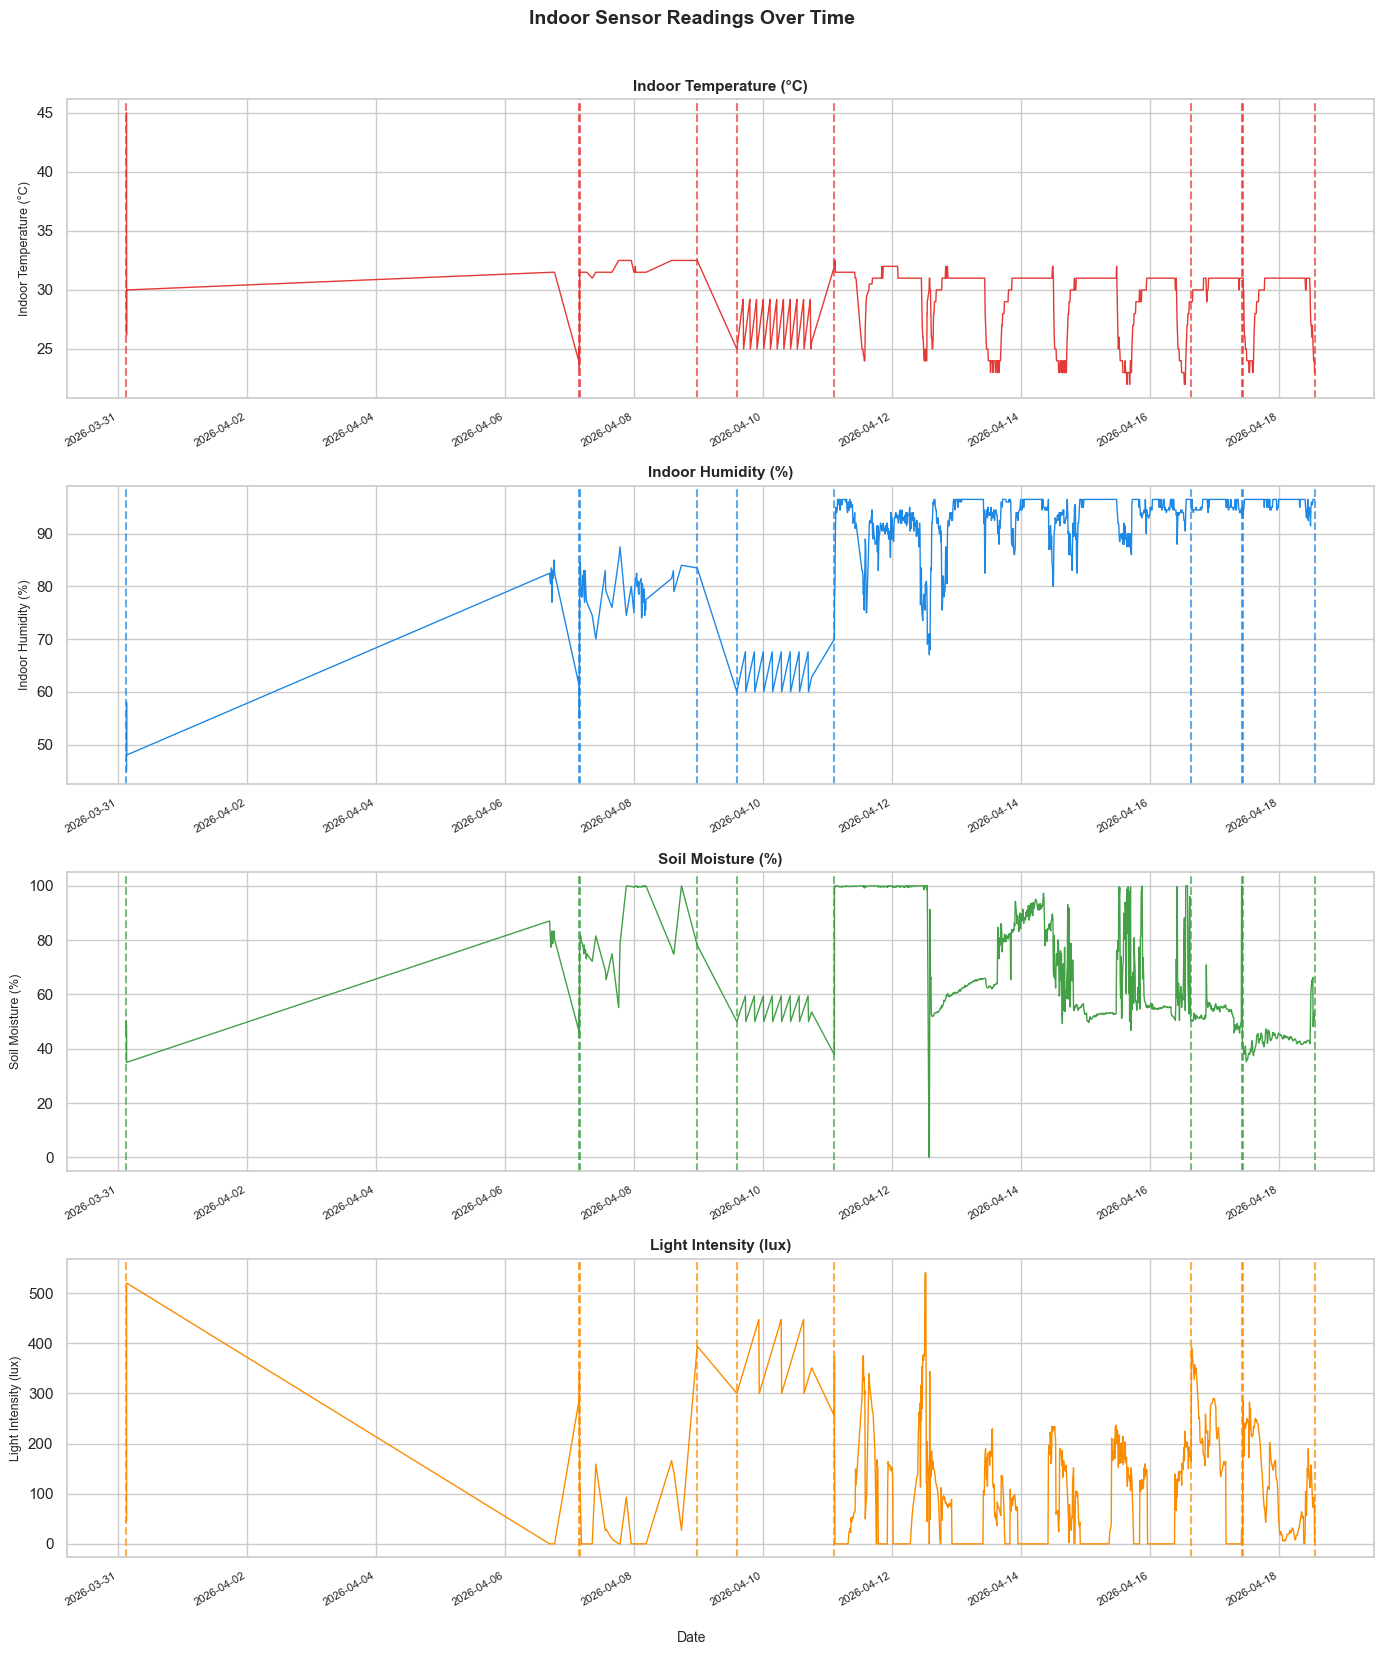

In [6]:
plot_cols = [c for c in [col_temp_in, col_hum_in, col_soil, col_light_lux] if c is not None]

label_map = {
    col_temp_in:    "Indoor Temperature (°C)",
    col_hum_in:     "Indoor Humidity (%)",
    col_soil:       "Soil Moisture (%)",
    col_light_lux:  "Light Intensity (lux)",
}

color_map = {
    col_temp_in:   "#E53935",
    col_hum_in:    "#1E88E5",
    col_soil:      "#43A047",
    col_light_lux: "#FB8C00",
}

if plot_cols:
    # Creates one subplot per sensor, all sharing the same x-axis (time)
    fig, axes = plt.subplots(len(plot_cols), 1, figsize=(14, 4 * len(plot_cols)), sharex=True)
    if len(plot_cols) == 1:
        axes = [axes]  # Ensure axes is always a list for consistent iteration below

    fig.suptitle("Indoor Sensor Readings Over Time", fontsize=14, fontweight="bold", y=1.01)

    stage_col_for_marker = col_stage_name if col_stage_name else col_stage
    if stage_col_for_marker:
        # Detect rows where the stage value changes — used to draw vertical stage-transition lines
        stage_changes = ag[stage_col_for_marker].astype(str).ne(ag[stage_col_for_marker].astype(str).shift(1))

    for ax, c in zip(axes, plot_cols):
        readable = label_map.get(c, c.replace("_", " ").title())
        color = color_map.get(c, "#546E7A")
        ax.plot(ag["ts"], ag[c], linewidth=1, color=color)
        ax.set_title(readable, fontsize=11, fontweight="bold", pad=6)
        ax.set_ylabel(readable, fontsize=9)
        ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
        ax.tick_params(axis="x", labelbottom=True, labelrotation=30, labelsize=8)
        plt.setp(ax.xaxis.get_majorticklabels(), ha="right")
        if stage_changes is not None:
            # Draw a dashed vertical line at every point the plant transitions to a new stage
            for t in ag.loc[stage_changes, "ts"]:
                ax.axvline(t, linestyle="--", alpha=0.7, linewidth=1.5, color=color)

    fig.text(0.5, -0.01, "Date", ha="center", fontsize=10)
    plt.tight_layout()
    plt.show()
else:
    print("No sensor columns found for time-series plotting.")

## 2.4a Stage Distribution and Class Imbalance

**Goal:** Quantify how many data points exist per growth stage to identify class imbalance before modeling.

**Method:** Bar chart of stage counts, ordered biologically and excluding the harvested end-state.

**Processes:**
- **Harvested exclusion:** filters out "harvested" rows as it's a terminal state, not a growth stage the model needs to predict
- **Biological ordering:** sorts bars as seedling → vegetative → bloom instead of alphabetically for intuitive readability
- **Count annotation:** displays the exact row count on top of each bar for quick imbalance assessment

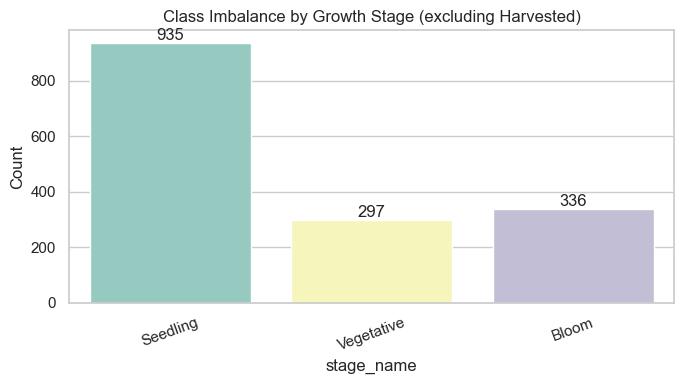

Stage counts (excluding Harvested):
stage_name
Seedling      935
Vegetative    297
Bloom         336
Name: count, dtype: int64


In [7]:
stage_col = col_stage_name if col_stage_name else col_stage
if stage_col is None:
    print('No stage column found; skip stage-based plots.')
else:
    stage_values = ag[stage_col].astype(str).str.strip()
    # Exclude 'harvested' since it's an end state, not a growth stage we want to model
    stage_values = stage_values[stage_values.str.lower() != 'harvested']
    counts = stage_values.value_counts()

    if counts.empty:
        print('No non-harvested stages found; skip stage-based plots.')
    else:
        # Force biological order (seedling → vegetative → bloom) instead of alphabetical
        stage_rank = {'seedling': 0, 'vegetative': 1, 'bloom': 2}
        ordered_labels = sorted(
            counts.index,
            key=lambda s: (stage_rank.get(str(s).strip().lower(), 99), str(s))
        )
        counts = counts.reindex(ordered_labels)

        plt.figure(figsize=(7, 4))
        sns.barplot(x=counts.index, y=counts.values, hue=counts.index, palette="Set3", legend=False)
        plt.title('Class Imbalance by Growth Stage (excluding Harvested)')
        plt.ylabel('Count')
        plt.xlabel(stage_col)
        plt.xticks(rotation=20)
        # Annotate exact count on top of each bar
        for i, v in enumerate(counts.values):
            plt.text(i, v, str(v), ha='center', va='bottom')
        plt.tight_layout()
        plt.show()

        print('Stage counts (excluding Harvested):')
        print(counts)

## 2.4b Sensor Distribution by Growth Stage

**Goal:** Show how each sensor reading is distributed within each growth stage to reveal stage-specific patterns.

**Method:** Horizontal box plots with one chart per sensor, grouped by growth stage.

**Processes:**
- **Per-sensor plots:** iterates over each detected sensor column and produces a separate box plot
- **Stage grouping:** y-axis is the growth stage, x-axis is the sensor value — making it easy to compare medians and spreads across stages

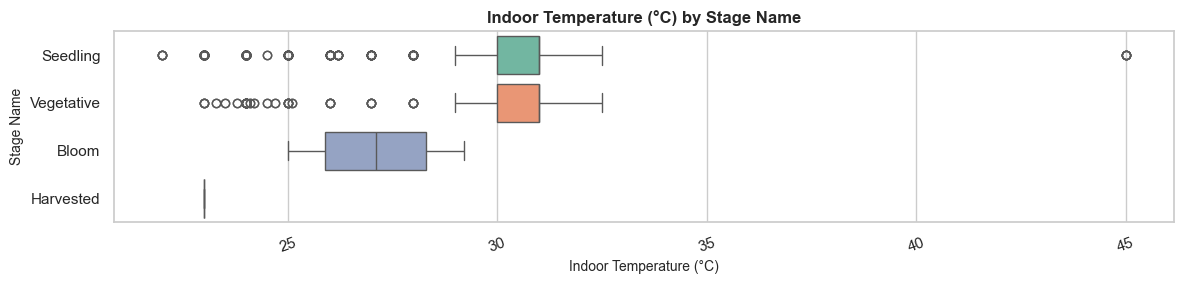

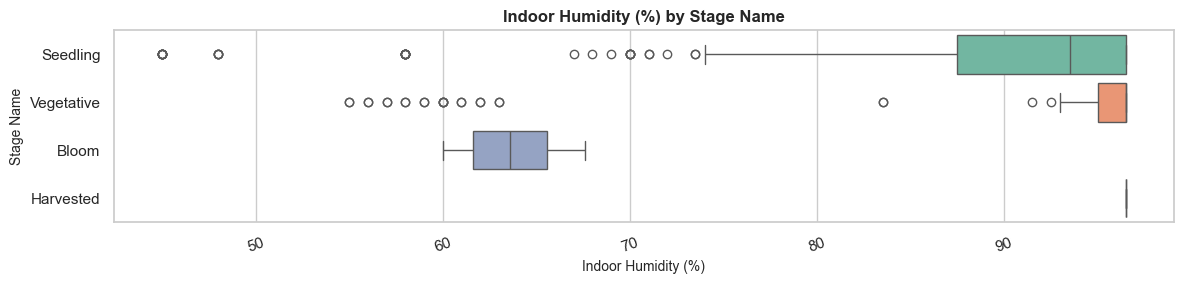

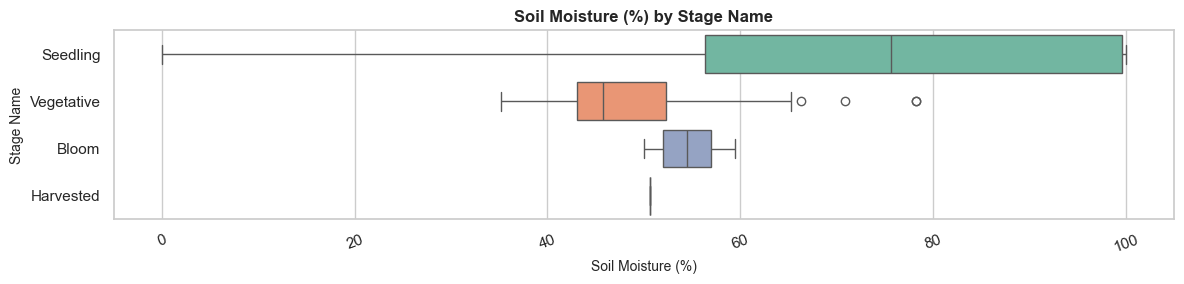

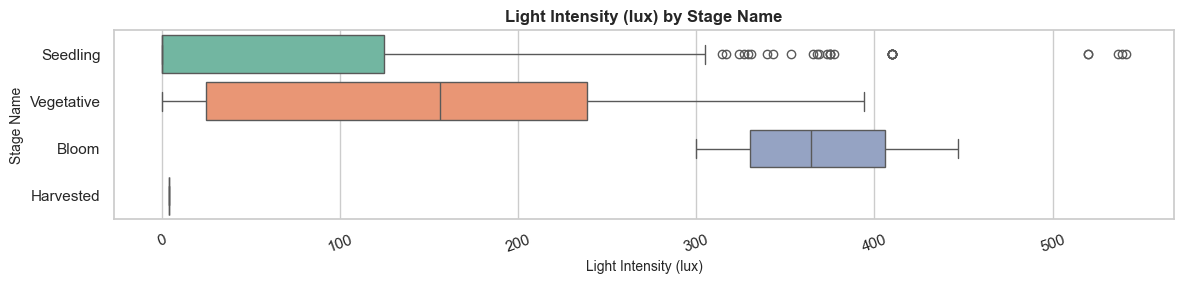

In [8]:
stage_col = col_stage_name if col_stage_name else col_stage

label_map = {
    col_temp_in:   "Indoor Temperature (°C)",
    col_hum_in:    "Indoor Humidity (%)",
    col_soil:      "Soil Moisture (%)",
    col_light_lux: "Light Intensity (lux)",
}

# Convert column name to readable title (e.g. "stage_name" → "Stage Name")
stage_label = stage_col.replace("_", " ").title() if stage_col else "Growth Stage"

if stage_col is not None:
    dist_cols = [c for c in [col_temp_in, col_hum_in, col_soil, col_light_lux] if c is not None]
    # One box plot per sensor — shows how each sensor's distribution differs across stages
    for c in dist_cols:
        readable = label_map.get(c, c.replace("_", " ").title())
        plt.figure(figsize=(12, 3))
        sns.boxplot(data=ag, x=c, y=stage_col, hue=stage_col, palette="Set2", legend=False)
        plt.title(f"{readable} by {stage_label}", fontsize=12, fontweight="bold")
        plt.xlabel(readable, fontsize=10)
        plt.ylabel(stage_label, fontsize=10)
        plt.xticks(rotation=20)
        plt.tight_layout()
        plt.show()

## 2.5a Indoor vs Outdoor Data Merging

**Goal:** Combine indoor and outdoor readings into a single hourly table for direct comparison.

**Method:** Aggregate both datasets to hourly means, then inner join on `hour_bucket`.

**Processes:**
- **Hourly aggregation:** averages all readings within each hour to align the two datasets on the same time resolution
- **Conditional aggregation:** only includes columns that were successfully detected — avoids errors if a sensor is missing
- **Inner join:** keeps only hours where both indoor and outdoor data exist, ensuring no NaNs from mismatched timestamps

In [9]:
# Build hourly averages for indoor sensors — only includes columns that were detected
indoor_agg = {}
if col_temp_in:
    indoor_agg['indoor_temp'] = (col_temp_in, 'mean')
if col_hum_in:
    indoor_agg['indoor_humidity'] = (col_hum_in, 'mean')
ag_hour = ag.groupby('hour_bucket').agg(**indoor_agg).reset_index() if indoor_agg else ag[['hour_bucket']].drop_duplicates()

# Same for outdoor — renames columns to fixed names (outdoor_temp, outdoor_humidity)
# so downstream code doesn't need to worry about the original DB column names
outdoor_agg = {}
if col_temp_out:
    outdoor_agg[col_temp_out_feat] = (col_temp_out, 'mean')
if col_hum_out:
    outdoor_agg[col_hum_out_feat] = (col_hum_out, 'mean')
wh_hour = wh.groupby('hour_bucket').agg(**outdoor_agg).reset_index() if outdoor_agg else wh[['hour_bucket']].drop_duplicates()

# Inner join on hour_bucket — only keeps hours where both indoor and outdoor data exist
merged_io = ag_hour.merge(wh_hour, on='hour_bucket', how='inner')
print('Indoor/outdoor merged rows:', len(merged_io))
display(merged_io.head())

Indoor/outdoor merged rows: 134


,hour_bucket,indoor_temp,indoor_humidity,outdoor_temp,outdoor_humidity
0,2026-04-13 00:00:00,31.0,96.250000,28.3,89.0
1,2026-04-13 01:00:00,31.0,96.333333,30.0,76.0
2,2026-04-13 02:00:00,31.0,96.500000,31.8,62.0
3,2026-04-13 03:00:00,31.0,96.500000,33.3,57.0
4,2026-04-13 04:00:00,31.0,96.500000,34.9,52.0


## 2.5b Indoor vs Outdoor Comparison Plot

**Goal:** Visually assess how much outdoor weather conditions influence the indoor growing enclosure.

**Method:** Overlaid line charts comparing indoor and outdoor temperature and humidity over time.

**Processes:**
- **Two separate charts:** one for temperature, one for humidity — plotted on the same time axis for direct comparison
- **Guard conditions:** skips plotting if either column is missing or the merged table is empty

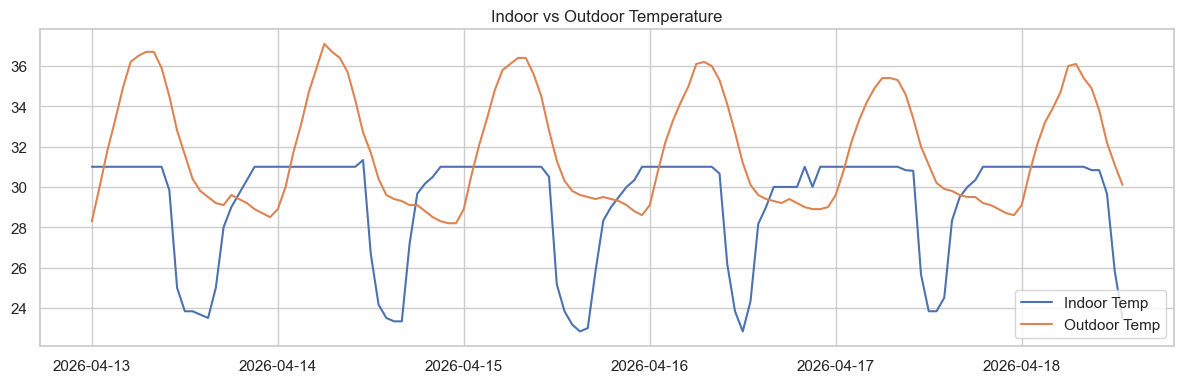

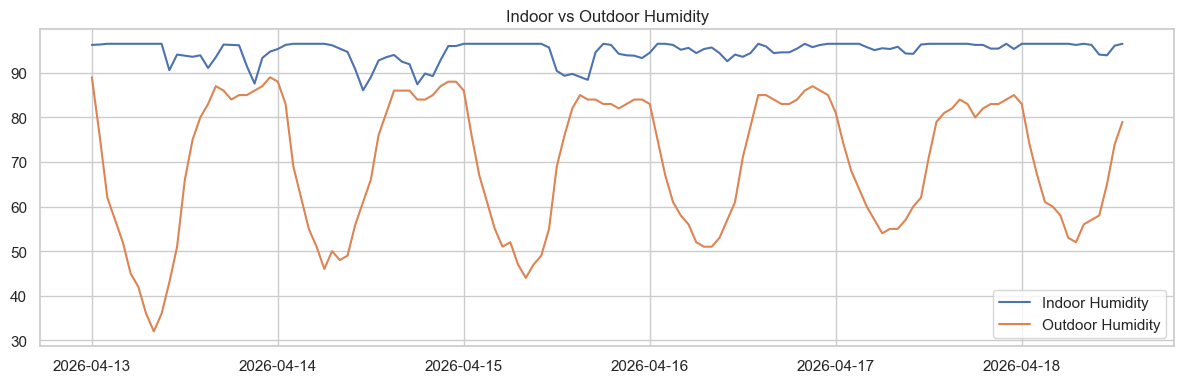

In [10]:
# Guard checks ensure we don't plot if columns are missing or the merge produced no rows
if 'indoor_temp' in merged_io.columns and col_temp_out_feat in merged_io.columns and not merged_io.empty:
    plt.figure(figsize=(12, 4))
    plt.plot(merged_io['hour_bucket'], merged_io['indoor_temp'], label='Indoor Temp')
    plt.plot(merged_io['hour_bucket'], merged_io[col_temp_out_feat], label='Outdoor Temp')
    plt.title('Indoor vs Outdoor Temperature')
    plt.legend()
    plt.tight_layout()
    plt.show()

if 'indoor_humidity' in merged_io.columns and col_hum_out_feat in merged_io.columns and not merged_io.empty:
    plt.figure(figsize=(12, 4))
    plt.plot(merged_io['hour_bucket'], merged_io['indoor_humidity'], label='Indoor Humidity')
    plt.plot(merged_io['hour_bucket'], merged_io[col_hum_out_feat], label='Outdoor Humidity')
    plt.title('Indoor vs Outdoor Humidity')
    plt.legend()
    plt.tight_layout()
    plt.show()

## 2.6 Correlation Heatmap

**Goal:** Identify linear relationships between all numeric sensor readings.

**Method:** Pearson correlation matrix visualized as a heatmap.

**Processes:**
- **Auto column selection:** only numeric columns are included, avoiding errors from text or datetime fields
- **Color anchoring:** `center=0` maps zero correlation to white, making positive (red) and negative (blue) relationships immediately clear

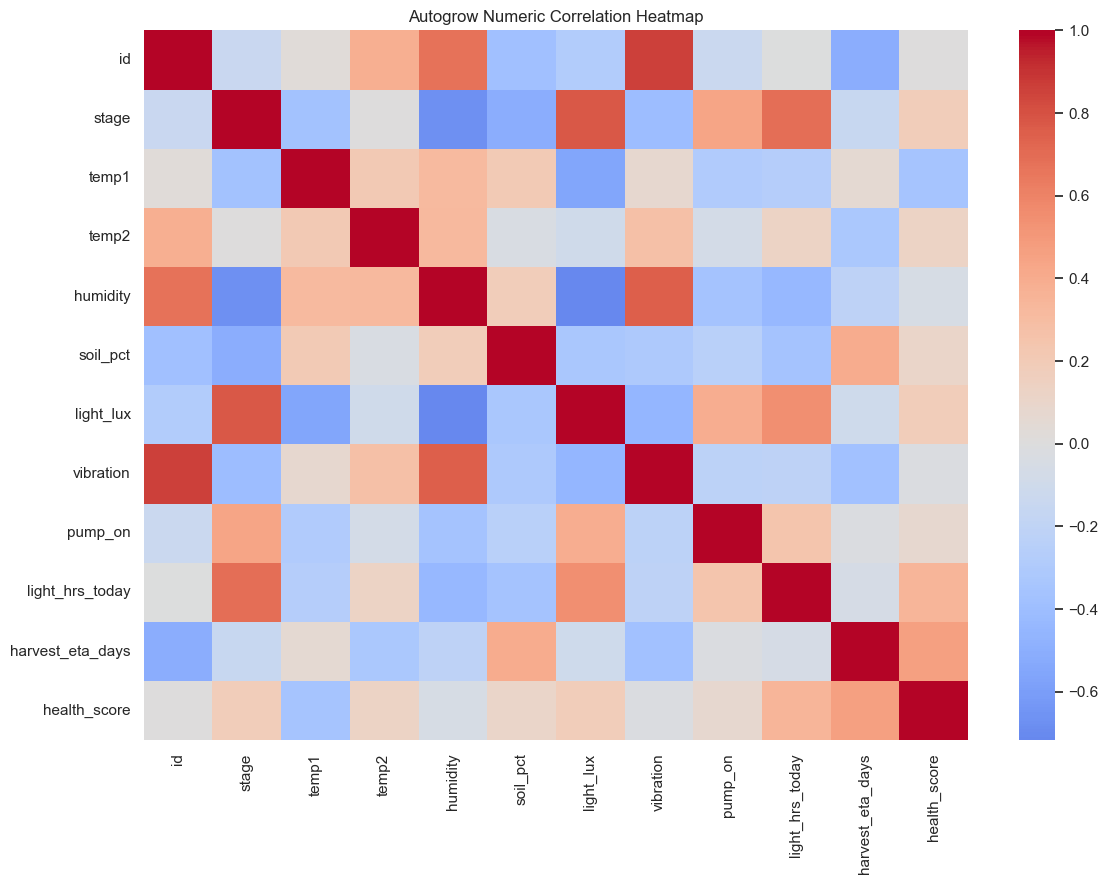

In [11]:
# Automatically selects only numeric columns — skips text/datetime columns that can't be correlated
numeric_cols = ag.select_dtypes(include=[np.number]).columns.tolist()
if len(numeric_cols) > 1:
    plt.figure(figsize=(12, 9))
    # center=0 ensures the colormap is anchored at zero — red = positive, blue = negative correlation
    sns.heatmap(ag[numeric_cols].corr(), cmap='coolwarm', center=0)
    plt.title('Autogrow Numeric Correlation Heatmap')
    plt.tight_layout()
    plt.show()

## 3) Complex Data Pre-Processing Pipeline
Pipeline steps are intentionally separated for traceable outputs.


## 3.1 Timestamp Alignment Check

**Goal:** Verify that indoor and outdoor datasets overlap in time before merging.

**Method:** Print row counts, unique hour buckets, and date ranges for both DataFrames.

**Processes:**
- **Row vs bucket count:** if hour buckets are far fewer than rows, multiple readings exist per hour — expected behavior
- **Time range overlap:** if `ag` and `wh` date ranges don't overlap, the merge will produce no usable rows

In [12]:
# Confirms row counts, hourly coverage, and time ranges before merging
print('Autogrow rows:', len(ag), '| Hour buckets:', ag['hour_bucket'].nunique())
print('Weather history rows:', len(wh), '| Hour buckets:', wh['hour_bucket'].nunique())
print('Autogrow start/end:', ag['ts'].min(), '->', ag['ts'].max())
print('Weather start/end:', wh['ts'].min(), '->', wh['ts'].max())

Autogrow rows: 1569 | Hour buckets: 231
Weather history rows: 192 | Hour buckets: 192
Autogrow start/end: 2026-03-31 03:02:57 -> 2026-04-18 13:18:29
Weather start/end: 2026-04-13 00:00:00 -> 2026-04-20 23:00:00


## 3.2 Outlier Detection (IQR Method)

**Goal:** Identify outliers in key numeric columns before deciding whether to remove them.

**Method:** Apply the IQR method to each target column — flagging values below Q1 − 1.5×IQR or above Q3 + 1.5×IQR as outliers.

**Processes:**
- **Column scope:** only columns that are defined (non-`None`) are checked — currently `col_soil` and `col_temp_in`
- **IQR bounds:** Q1, Q3, and the lower/upper fences are computed per column and stored for inspection
- **Outlier count:** the number of flagged rows is recorded per column but rows are not dropped here — removal happens in the next step

In [13]:
prep = ag.copy()
outlier_cols = [c for c in [col_soil, col_temp_in] if c is not None]
outlier_stats = []

for c in outlier_cols:
    s = pd.to_numeric(prep[c], errors='coerce')
    # IQR method: anything below Q1 - 1.5×IQR or above Q3 + 1.5×IQR is flagged as an outlier
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    mask = (s < low) | (s > high)
    outlier_stats.append({
        'column': c,
        'q1': q1,
        'q3': q3,
        'low': low,
        'high': high,
        'outlier_count': int(mask.sum())
    })

# Display stats only — rows are not removed yet, that happens in the next step
outlier_stats_df = pd.DataFrame(outlier_stats)
display(outlier_stats_df)

,column,q1,q3,low,high,outlier_count
0,soil_pct,52.5,81.8,8.55,125.75,4
1,temp1,27.1,31.0,21.25,36.85,6


## 3.3 Outlier Removal (IQR Filter)

**Goal:** Drop rows containing outliers in any of the target columns to produce a clean working DataFrame.

**Method:** Build a combined boolean mask across all target columns and retain only rows that fall within IQR bounds (or are NaN) in every column simultaneously.

**Processes:**
- **Joint mask:** rows are removed if *any* target column is out of bounds — `keep` starts as all-`True` and is narrowed with `&=` per column
- **NaN tolerance:** missing values are preserved (`s.isna()` is allowed through) so NaN rows are not incorrectly dropped as outliers
- **Row count report:** before/after/removed counts are printed to confirm how many rows the filter discards

In [14]:
keep = pd.Series(True, index=prep.index)
for c in outlier_cols:
    s = pd.to_numeric(prep[c], errors='coerce')
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    keep &= s.between(low, high) | s.isna()

prep_iqr = prep[keep].copy()
print('Rows before IQR filter:', len(prep))
print('Rows after IQR filter :', len(prep_iqr))
print('Rows removed          :', len(prep) - len(prep_iqr))


Rows before IQR filter: 1569
Rows after IQR filter : 1559
Rows removed          : 10


## 3.4 Isolation Forest — Multivariate Anomaly Detection

**Goal:** Catch multivariate anomalies that univariate IQR filtering misses — sensor readings that are individually plausible but abnormal in combination.

**Method:** Run scikit-learn's Isolation Forest across all available sensor columns simultaneously, flagging the bottom 2% of rows as anomalies, then visualise inliers vs outliers in 2D sensor space.

**Processes:**
- **Column scope:** uses whichever of `col_soil`, `col_temp_in`, `col_hum_in`, `col_light_lux` are defined and present — requires at least 2 columns to proceed; falls back to IQR-only data otherwise
- **Median imputation:** NaNs are filled with column medians before fitting so missing values don't block the model
- **Contamination rate:** `contamination=0.02` tells the model to treat 2% of rows as outliers — tune this if the dataset is noisier or cleaner than expected
- **Scatter plot:** the first two sensor columns are plotted against each other with blue/red colouring to show where the model drew the inlier boundary
- **Pipeline output:** `prep_clean` contains only IQR-passing, IF-inlier rows and is the DataFrame carried forward

Isolation Forest | Features: ['soil_pct', 'temp1', 'humidity', 'light_lux']
  Total rows      : 1559
  IF Outliers     : 32 (2.05%)
  Clean inliers   : 1527


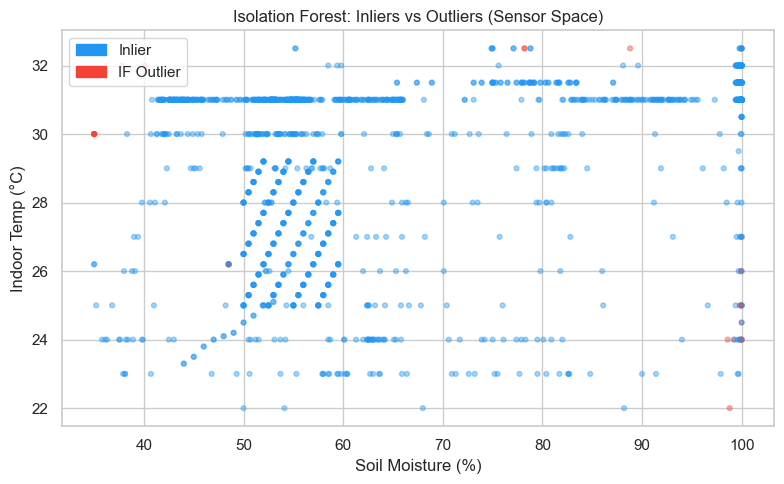


Rows after IQR + IF pipeline: 1527 (removed 32 additional rows by IF)


In [15]:
iso_cols = [c for c in [col_soil, col_temp_in, col_hum_in, col_light_lux]
            if c is not None and c in prep_iqr.columns]

if len(iso_cols) >= 2:
    iso_input = prep_iqr[iso_cols].copy()

    # Fill NaNs with column medians so missing values don't block the model
    iso_imputer = SimpleImputer(strategy='median')
    iso_input_imp = iso_imputer.fit_transform(iso_input)

    # contamination=0.02 tells the model to treat ~2% of rows as anomalies
    iso_forest = IsolationForest(contamination=0.02, random_state=42, n_jobs=-1)
    iso_labels = iso_forest.fit_predict(iso_input_imp)  # 1 = inlier, -1 = outlier
    prep_iqr['isolation_flag'] = iso_labels

    n_outliers = (iso_labels == -1).sum()
    n_total = len(iso_labels)
    print(f'Isolation Forest | Features: {iso_cols}')
    print(f'  Total rows      : {n_total}')
    print(f'  IF Outliers     : {n_outliers} ({100*n_outliers/n_total:.2f}%)')
    print(f'  Clean inliers   : {n_total - n_outliers}')

    # Scatter the first two sensor axes — enough to see the inlier boundary visually
    colors = ['#2196F3' if v == 1 else '#F44336' for v in iso_labels]
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.scatter(iso_input_imp[:, 0], iso_input_imp[:, 1],
               c=colors, alpha=0.4, s=12)
    ax.legend(handles=[
        mpatches.Patch(color='#2196F3', label='Inlier'),
        mpatches.Patch(color='#F44336', label='IF Outlier')
    ])

    # Map raw column names to readable axis labels
    label_map = {
        col_soil:      'Soil Moisture (%)',
        col_temp_in:   'Indoor Temp (°C)',
        col_hum_in:    'Indoor Humidity (%)',
        col_light_lux: 'Light Intensity (lux)',
    }
    ax.set_xlabel(label_map.get(iso_cols[0], iso_cols[0].replace('_', ' ').title()))
    ax.set_ylabel(label_map.get(iso_cols[1], iso_cols[1].replace('_', ' ').title()))
    ax.set_title('Isolation Forest: Inliers vs Outliers (Sensor Space)')
    plt.tight_layout()
    plt.show()

    # Keep only inlier rows; drop the flag column before passing data forward
    prep_clean = prep_iqr[prep_iqr['isolation_flag'] == 1].drop(columns=['isolation_flag']).copy()
    print(f'\nRows after IQR + IF pipeline: {len(prep_clean)} '
          f'(removed {len(prep_iqr) - len(prep_clean)} additional rows by IF)')
else:
    # Not enough sensor columns to run multivariate detection — skip IF entirely
    print('Not enough sensor columns for Isolation Forest; using IQR-only filtered data.')
    prep_clean = prep_iqr.copy()

## 3.5 Null Audit After Cleaning Pipeline

**Goal:** Confirm which columns still contain missing values after the full IQR + Isolation Forest cleaning pipeline.

**Method:** Count NaNs per column, sort descending, and display only columns that still have at least one null.

**Processes:**
- **Scope:** runs on `prep_clean` — the final output of the IQR + IF pipeline — so any nulls shown here survived both cleaning stages
- **Display filter:** columns with zero nulls are hidden to keep the output concise; an empty table means the dataset is fully clean
- **Row count:** printed alongside the null table as a quick sanity check on how many rows remain

In [16]:
# Null audit after full cleaning pipeline (IQR + Isolation Forest)
nulls_after_clean = prep_clean.isna().sum().sort_values(ascending=False)
display(nulls_after_clean[nulls_after_clean > 0].to_frame('null_count'))
print(f'Rows in prep_clean: {len(prep_clean)}')

,null_count


Rows in prep_clean: 1527


## 3.6 Outdoor Feature Integration

**Goal:** Enrich the indoor sensor data with outdoor weather context — temperature, humidity, and daylight hours — by merging on time keys.

**Method:** Aggregate outdoor weather readings to hourly buckets and daily daylight duration, then left-merge both onto `feat` so every indoor row gains outdoor context where available.

**Processes:**
- **Outdoor temp & humidity:** hourly means are computed from `wh` only for columns that are defined — undefined columns are filled with `np.nan` rather than skipped entirely, so downstream code always finds the expected feature columns
- **Daylight hours:** sunrise and sunset are parsed from `wc`, timezone info is stripped for consistency, and the difference in seconds is converted to decimal hours — averaged per date before merging
- **Sunrise/sunset column discovery:** `first_existing()` handles variant column naming (`sunrise_utc` vs `sunrise`) so the logic is dataset-agnostic
- **Date key:** `feat['date']` is derived from `ts` and used as the merge key for daylight hours; the column is added temporarily and remains in the table after the merge
- **Left merges:** both joins are `how='left'` so indoor rows are never dropped if outdoor data is missing for a given hour or date

In [17]:
feat = prep_clean.copy()

# Build aggregation spec only for outdoor columns that are defined
outdoor_agg = {}
if col_temp_out:
    outdoor_agg[col_temp_out_feat] = (col_temp_out, 'mean')
if col_hum_out:
    outdoor_agg[col_hum_out_feat] = (col_hum_out, 'mean')

if outdoor_agg:
    # Aggregate outdoor readings to hourly means, then left-join onto indoor rows
    wh_hourly_feat = wh.groupby('hour_bucket').agg(**outdoor_agg).reset_index()
    feat = feat.merge(wh_hourly_feat, on='hour_bucket', how='left')
else:
    # No outdoor columns available — add empty placeholders so downstream code doesn't break
    feat[col_temp_out_feat] = np.nan
    feat[col_hum_out_feat] = np.nan

# Handle variant column naming across datasets (sunrise_utc vs sunrise, etc.)
col_sunrise = first_existing(wc.columns, ['sunrise_utc', 'sunrise'])
col_sunset = first_existing(wc.columns, ['sunset_utc', 'sunset'])

if col_sunrise and col_sunset:
    wc_tmp = wc.copy()

    # Parse to datetime and strip timezone so arithmetic works without tz conflicts
    wc_tmp['sunrise_dt'] = pd.to_datetime(wc_tmp[col_sunrise], errors='coerce', utc=True).dt.tz_localize(None)
    wc_tmp['sunset_dt'] = pd.to_datetime(wc_tmp[col_sunset], errors='coerce', utc=True).dt.tz_localize(None)

    # Convert timedelta to decimal hours
    wc_tmp['daylight_hours'] = (wc_tmp['sunset_dt'] - wc_tmp['sunrise_dt']).dt.total_seconds() / 3600

    # Derive date key — prefer ts if available, fall back to sunrise date
    if 'ts' in wc_tmp.columns and wc_tmp['ts'].notna().any():
        wc_tmp['date'] = wc_tmp['ts'].dt.date
    else:
        wc_tmp['date'] = wc_tmp['sunrise_dt'].dt.date

    daylight_df = wc_tmp.groupby('date', as_index=False)['daylight_hours'].mean()

    feat['date'] = feat['ts'].dt.date
    feat = feat.merge(daylight_df, on='date', how='left')
else:
    # Sunrise/sunset columns missing — fill with NaN to keep schema consistent
    feat['daylight_hours'] = np.nan

print('Feature table shape after merge:', feat.shape)
display(feat.head())

Feature table shape after merge: (1527, 21)


,id,ts,stage,stage_name,spectrum,temp1,temp2,humidity,soil_pct,light_lux,vibration,pump_on,pump_status,light_hrs_today,harvest_eta_days,health_score,hour_bucket,outdoor_temp,outdoor_humidity,date,daylight_hours
0,10,2026-03-31 03:13:40,0,Seedling,OFF,26.2,0.0,58.0,48.5,410.0,0,0,OK,0.0,0,0,2026-03-31 03:00:00,NaN,NaN,2026-03-31,NaN
1,176,2026-03-31 03:13:40,0,Seedling,,26.2,26.2,58.0,48.5,410.0,0,0,OK,0.0,0,0,2026-03-31 03:00:00,NaN,NaN,2026-03-31,NaN
2,11,2026-03-31 03:13:46,0,Seedling,OFF,26.2,0.0,58.0,35.0,410.0,0,0,OK,0.0,0,0,2026-03-31 03:00:00,NaN,NaN,2026-03-31,NaN
3,177,2026-03-31 03:13:46,0,Seedling,,26.2,26.2,58.0,35.0,410.0,0,0,OK,0.0,0,0,2026-03-31 03:00:00,NaN,NaN,2026-03-31,NaN
4,181,2026-04-06 16:39:46,0,Seedling,,31.5,31.5,82.5,87.1,0.0,0,0,OK,0.0,0,0,2026-04-06 16:00:00,NaN,NaN,2026-04-06,NaN


## 3.7 Domain Feature Engineering

**Goal:** Construct agronomic and temporal features that encode plant-stage context and cyclical time patterns for use in modelling.

**Method:** Map each row's growth stage to target thresholds, compute deviations from those targets, and encode hour-of-day as sine/cosine components.

**Processes:**
- **Stage label:** resolved from `col_stage_name` → `col_stage` → `'unknown'`, normalised to lowercase for consistent mapping
- **Deviation features:** `soil_deviation` and `light_deficit` measure signed distance from per-stage agronomic targets; `temp_delta` captures indoor vs outdoor temperature gap
- **Cyclic hour encoding:** sine/cosine transform on hour-of-day so the model treats 23:00 and 00:00 as adja

In [18]:
# Resolve stage column — prefer human-readable name over numeric code
stage_col = col_stage_name if col_stage_name else col_stage
feat['stage_label'] = feat[stage_col].astype(str) if stage_col else 'unknown'
stage_key = feat['stage_label'].str.lower().str.strip()

if col_soil:
    # Ideal soil moisture (%) per growth stage — deviation = actual minus target
    soil_target_map = {'seedling': 70, 'vegetative': 60, 'bloom': 50, 'harvested': 40}
    feat['soil_target'] = stage_key.map(soil_target_map).fillna(60)
    feat['soil_deviation'] = pd.to_numeric(feat[col_soil], errors='coerce') - feat['soil_target']

if col_temp_in and col_temp_out_feat in feat.columns:
    # Positive = warmer indoors, negative = cooler indoors than outside
    feat['temp_delta'] = pd.to_numeric(feat[col_temp_in], errors='coerce') - pd.to_numeric(feat[col_temp_out_feat], errors='coerce')

if col_light_hrs:
    # Required light hours per stage; deficit > 0 means the plant is underlit
    light_target_map = {'seedling': 6, 'vegetative': 12, 'bloom': 12, 'harvested': 0}
    feat['light_target'] = stage_key.map(light_target_map).fillna(12)
    feat['light_deficit'] = feat['light_target'] - pd.to_numeric(feat[col_light_hrs], errors='coerce')

# Sine/cosine encoding keeps hour circular — 23:00 and 00:00 stay adjacent
feat['hour'] = feat['ts'].dt.hour
feat['hour_sin'] = np.sin(2 * np.pi * feat['hour'] / 24)
feat['hour_cos'] = np.cos(2 * np.pi * feat['hour'] / 24)

# Preview only columns that exist in this dataset
preview_cols = [c for c in [
    'ts', 'stage_label', col_temp_in, col_hum_in, col_soil, col_light_hrs,
    col_temp_out_feat, col_hum_out_feat,
    'soil_deviation', 'temp_delta', 'light_deficit', 'hour_sin', 'hour_cos', 'daylight_hours'
] if c is not None and c in feat.columns]
display(feat[preview_cols].head())

,ts,stage_label,temp1,humidity,soil_pct,light_hrs_today,outdoor_temp,outdoor_humidity,soil_deviation,temp_delta,light_deficit,hour_sin,hour_cos,daylight_hours
0,2026-03-31 03:13:40,Seedling,26.2,58.0,48.5,0.0,NaN,NaN,-21.5,NaN,6.0,0.707107,0.707107,NaN
1,2026-03-31 03:13:40,Seedling,26.2,58.0,48.5,0.0,NaN,NaN,-21.5,NaN,6.0,0.707107,0.707107,NaN
2,2026-03-31 03:13:46,Seedling,26.2,58.0,35.0,0.0,NaN,NaN,-35.0,NaN,6.0,0.707107,0.707107,NaN
3,2026-03-31 03:13:46,Seedling,26.2,58.0,35.0,0.0,NaN,NaN,-35.0,NaN,6.0,0.707107,0.707107,NaN
4,2026-04-06 16:39:46,Seedling,31.5,82.5,87.1,0.0,NaN,NaN,17.1,NaN,6.0,-0.866025,-0.500000,NaN


## 3.8 Class Distribution & SMOTE Availability Check

**Goal:** Inspect growth-stage class balance and confirm whether SMOTE can be used to correct it before modelling.

**Method:** Count rows per stage label, then attempt to import SMOTE — setting a flag that downstream training code reads to choose between oversampling and `class_weight` fallback.

**Processes:**
- **Class counts:** printed per stage to reveal imbalance — a heavily skewed distribution may bias the model toward majority stages
- **SMOTE flag:** `smote_available` is set here and used later to decide the resampling strategy — if the import fails, training falls back to `class_weight='balanced'`

In [19]:
smote_available = False

# 1. Calculate how many examples we have for each growth stage
if col_stage_name and col_stage_name in feat.columns or col_stage and col_stage in feat.columns:
    stage_col_check = col_stage_name if col_stage_name else col_stage
    counts = feat[stage_col_check].astype(str).value_counts()
    print('Class distribution:')
    print(counts)

# 2. Load the SMOTE tool (already guaranteed by the ensure_package check at the top)
try:
    from imblearn.over_sampling import SMOTE
    smote_available = True
    print('SMOTE available: True')
except ImportError:
    print('SMOTE available: False (fallback to class_weight)')


Class distribution:
stage_name
Seedling      895
Bloom         336
Vegetative    295
Harvested       1
Name: count, dtype: int64
SMOTE available: True


## 4.1 Model Data Preparation & Train/Test Split

**Goal:** Build a clean, time-ordered modelling DataFrame and split it into train/test sets without leaking future data into training.

**Method:** Filter out rare classes and invalid rows, select available features, then split on a fixed timestamp — falling back to an 80/20 quantile split if the cutoff falls outside the data range.

**Processes:**
- **Rare class filter:** stages with fewer than 5 rows are dropped to prevent the model from training on classes it cannot learn reliably
- **Feature selection:** only candidates that are defined and present in `model_df` are included — adapts automatically to partial datasets
- **Time-based split:** uses `2026-04-15` as the cutoff if it falls within the data range; otherwise splits at the 80th percentile timestamp — ensures test set always reflects the most recent observations
- **Leak prevention:** rows are sorted by `ts` before splitting so no future readings bleed into training

In [20]:
# Resolve stage column — raise early if neither is defined
stage_col = col_stage_name if col_stage_name else col_stage
if stage_col is None:
    raise ValueError('No stage label found for classification task.')

# Sort chronologically to ensure time-based split is valid
model_df = feat.dropna(subset=['ts']).sort_values('ts').copy()
model_df['target_stage'] = model_df[stage_col].astype(str)

# Drop stages with fewer than 5 rows — too sparse to train or evaluate reliably
vc = model_df['target_stage'].value_counts()
valid_classes = vc[vc >= 5].index
model_df = model_df[model_df['target_stage'].isin(valid_classes)].copy()

# Keep only feature columns that are defined and present in this dataset
feature_candidates = [
    col_temp_in, col_hum_in, col_soil, col_light_lux, col_light_hrs,
    col_temp_out_feat, col_hum_out_feat,
    'soil_deviation', 'temp_delta', 'light_deficit',
    'hour_sin', 'hour_cos', 'daylight_hours'
]
X_cols = [c for c in feature_candidates if c is not None and c in model_df.columns]

# Use fixed cutoff if it falls within the data range, otherwise fall back to 80th percentile
cutoff = pd.Timestamp('2026-04-15')
split_ts = cutoff if model_df['ts'].min() < cutoff < model_df['ts'].max() else model_df['ts'].quantile(0.8)

train_mask = model_df['ts'] < split_ts
test_mask  = model_df['ts'] >= split_ts

X_train = model_df.loc[train_mask, X_cols].copy()
X_test  = model_df.loc[test_mask,  X_cols].copy()
y_train = model_df.loc[train_mask, 'target_stage'].copy()
y_test  = model_df.loc[test_mask,  'target_stage'].copy()

print('Rows:', len(model_df), '| Train:', len(X_train), '| Test:', len(X_test), '| Split:', split_ts)
print('Features:', X_cols)
print('Train class counts:')
print(y_train.value_counts())

Rows: 1526 | Train: 1013 | Test: 513 | Split: 2026-04-15 00:00:00
Features: ['temp1', 'humidity', 'soil_pct', 'light_lux', 'light_hrs_today', 'outdoor_temp', 'outdoor_humidity', 'soil_deviation', 'temp_delta', 'light_deficit', 'hour_sin', 'hour_cos', 'daylight_hours']
Train class counts:
target_stage
Seedling      657
Bloom         336
Vegetative     20
Name: count, dtype: int64


## 4.2 Imputation & SMOTE Balancing

**Goal:** Produce a clean, class-balanced training set ready for model fitting — without leaking any imputation statistics from the test set.

**Method:** Strip all-NaN columns, impute remaining nulls with column medians fitted on train only, then apply SMOTE to oversample minority classes if available.

**Processes:**
- **All-NaN column drop:** columns with no valid values are removed before imputation to prevent shape mismatches between train and test
- **Imputation:** median strategy fitted on `X_train_bal` and applied to both splits — test set never influences the imputer
- **SMOTE k-neighbour guard:** `k_neighbors` is capped at `min_class - 1` to avoid SMOTE crashing when a class has very few samples
- **Graceful fallback:** if SMOTE is unavailable or the smallest class has only 1 row, imputed training data is used as-is

In [21]:
X_train_bal, y_train_bal = X_train.copy(), y_train.copy()

# Remove columns that are entirely NaN — imputer can't handle them and they carry no signal
_cols_valid  = [c for c in X_cols if X_train_bal[c].notna().any()]
X_train_bal  = X_train_bal[_cols_valid]
X_test       = X_test[_cols_valid]
X_cols       = _cols_valid
X_cols_clean = _cols_valid

# Fit imputer on train only — transform both splits to prevent leakage
_smote_imputer = SimpleImputer(strategy='median')
X_train_imp = pd.DataFrame(
    _smote_imputer.fit_transform(X_train_bal),
    columns=X_cols_clean,
    index=X_train_bal.index
)
X_test = pd.DataFrame(
    _smote_imputer.transform(X_test),
    columns=X_cols_clean,
    index=X_test.index
)

if 'smote_available' in globals() and smote_available:
    min_class  = y_train_bal.value_counts().min()
    # Cap k_neighbors so SMOTE doesn't crash on very small minority classes
    k_neighbors = max(1, min(5, int(min_class) - 1))

    if min_class > 1 and k_neighbors >= 1:
        sm = SMOTE(random_state=42, k_neighbors=k_neighbors)
        X_bal_arr, y_bal_arr = sm.fit_resample(X_train_imp, y_train_bal)
        X_train_bal = pd.DataFrame(X_bal_arr, columns=X_cols_clean)
        y_train_bal = pd.Series(y_bal_arr)
        print('Applied SMOTE. Balanced class counts:')
        print(y_train_bal.value_counts())
    else:
        # Smallest class has only 1 sample — SMOTE cannot generate neighbours
        X_train_bal = X_train_imp.copy()
        print('SMOTE skipped: not enough samples in smallest class.')
else:
    X_train_bal = X_train_imp.copy()
    print('SMOTE not available; using imputed training data.')

print(f'X_train_bal shape: {X_train_bal.shape}  X_test shape: {X_test.shape}')
print(f'Active features ({len(X_cols_clean)}): {X_cols_clean}')
print('Train class distribution after balancing:')
print(y_train_bal.value_counts())

Applied SMOTE. Balanced class counts:
target_stage
Seedling      657
Vegetative    657
Bloom         657
Name: count, dtype: int64
X_train_bal shape: (1971, 12)  X_test shape: (513, 12)
Active features (12): ['temp1', 'humidity', 'soil_pct', 'light_lux', 'light_hrs_today', 'outdoor_temp', 'outdoor_humidity', 'soil_deviation', 'temp_delta', 'light_deficit', 'hour_sin', 'hour_cos']
Train class distribution after balancing:
target_stage
Seedling      657
Vegetative    657
Bloom         657
Name: count, dtype: int64


## 4.3 XGBoost Training & Evaluation

**Goal:** Train an XGBoost classifier with time-aware cross-validation and evaluate it on the holdout set.

**Method:** Use `TimeSeriesSplit` CV to estimate generalisation without leaking future folds into past, then fit a final model on the full balanced training set and evaluate against the holdout.

**Processes:**
- **TimeSeriesSplit:** fold count is clamped to `min(5, len(X_train) - 1)` to handle small datasets without crashing; each fold respects chronological order
- **Label encoding:** string stage labels are integer-encoded for XGBoost and decoded back to strings before evaluation so metrics and reports stay human-readable
- **Holdout evaluation:** F1-macro, classification report, and confusion matrix are all computed on `X_test_cv` — data the model never saw during CV or fitting
- **Results table:** XGBoost row is upserted into `results_df` (deduped by model name, re-sorted by F1) for comparison across all models trained in this notebook
- **Model store:** fitted model and label encoder are saved to `fitted_models` for downstream SHAP analysis

TimeSeriesSplit CV F1-macro per fold: [1.     0.4859 1.     1.     1.    ]
Mean: 0.8972  Std: 0.2056


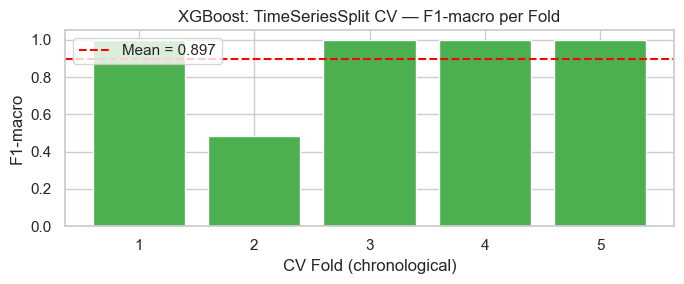


XGBoost Holdout F1-macro: 0.3169
              precision    recall  f1-score   support

    Seedling       0.46      1.00      0.63       238
  Vegetative       0.00      0.00      0.00       275

    accuracy                           0.46       513
   macro avg       0.23      0.50      0.32       513
weighted avg       0.22      0.46      0.29       513



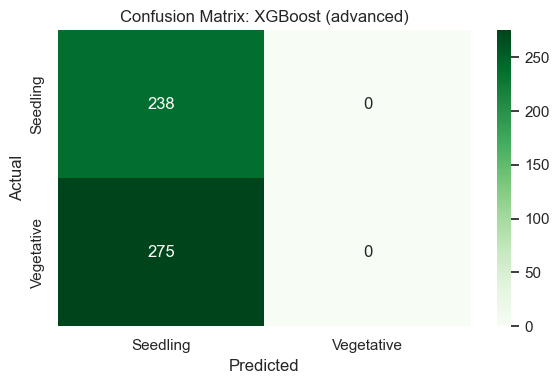

,model,f1_macro
0,XGBoost (advanced),0.316911


XGBoost stored in fitted_models.


In [22]:
# Data is already imputed from 4.2 — copy directly, no second imputer needed
X_train_cv = X_train_bal.copy()
X_test_cv  = X_test.copy()

# Encode string stage labels to integers for XGBoost
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train_bal.astype(str))
y_test_str  = y_test.astype(str)

xgb_clf = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

# Clamp n_splits so CV doesn't crash on small training sets
n_splits = min(5, max(2, len(X_train_cv) - 1))
tscv     = TimeSeriesSplit(n_splits=n_splits)
cv_scores = cross_val_score(
    xgb_clf, X_train_cv, y_train_enc,
    cv=tscv, scoring='f1_macro'
)
print('TimeSeriesSplit CV F1-macro per fold:', np.round(cv_scores, 4))
print(f'Mean: {cv_scores.mean():.4f}  Std: {cv_scores.std():.4f}')

plt.figure(figsize=(7, 3))
plt.bar(range(1, len(cv_scores) + 1), cv_scores, color='#4CAF50')
plt.axhline(cv_scores.mean(), linestyle='--', color='red',
            label=f'Mean = {cv_scores.mean():.3f}')
plt.xlabel('CV Fold (chronological)')
plt.ylabel('F1-macro')
plt.title('XGBoost: TimeSeriesSplit CV — F1-macro per Fold')
plt.legend()
plt.tight_layout()
plt.show()

# Fit on full balanced training set, then decode predictions back to string labels
xgb_clf.fit(X_train_cv, y_train_enc)
y_pred_xgb = le.inverse_transform(xgb_clf.predict(X_test_cv))

xgb_f1 = f1_score(y_test_str, y_pred_xgb, average='macro', zero_division=0)
print(f'\nXGBoost Holdout F1-macro: {xgb_f1:.4f}')
print(classification_report(y_test_str, y_pred_xgb, zero_division=0))

labels_xgb = sorted(y_test_str.unique())
cm_xgb     = confusion_matrix(y_test_str, y_pred_xgb, labels=labels_xgb)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Greens',
            xticklabels=labels_xgb, yticklabels=labels_xgb)
plt.title('Confusion Matrix: XGBoost (advanced)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# Upsert into results_df — dedupe by model name, keep sorted by F1 descending
xgb_row = pd.DataFrame([{'model': 'XGBoost (advanced)', 'f1_macro': xgb_f1}])
if 'results_df' in globals() and isinstance(results_df, pd.DataFrame) and not results_df.empty:
    results_df = pd.concat(
        [results_df[results_df['model'] != 'XGBoost (advanced)'], xgb_row],
        ignore_index=True
    ).sort_values('f1_macro', ascending=False).reset_index(drop=True)
else:
    results_df = xgb_row.copy()
display(results_df)

# Store model + encoder together so SHAP analysis can access both
if 'fitted_models' not in globals():
    fitted_models = {}
fitted_models['XGBoost (advanced)'] = (xgb_clf, le)
print('XGBoost stored in fitted_models.')

## 4.4 Baseline & Ensemble Model Training

**Goal:** Train and compare three classifiers — a Decision Tree baseline, a k-NN baseline, and a Random Forest ensemble — against the same train/test split.

**Method:** Each model is wrapped in a pipeline that handles imputation (and scaling for k-NN) internally, then evaluated on the holdout set with F1-macro, a classification report, and a confusion matrix.

**Processes:**
- **Pipeline design:** imputation is baked into each pipeline so no external imputer state leaks between models; k-NN additionally scales features since it is distance-based
- **Class imbalance:** Decision Tree and Random Forest use `class_weight='balanced'` as a lightweight alternative to SMOTE
- **Unified loop:** all models share the same fit → predict → report → plot flow; fitted pipelines are stored in `fitted_models` for downstream SHAP or inspection


Decision Tree (baseline) | F1-macro=0.2365
              precision    recall  f1-score   support

       Bloom       0.00      0.00      0.00         0
    Seedling       0.55      1.00      0.71       238
  Vegetative       0.00      0.00      0.00       275

    accuracy                           0.46       513
   macro avg       0.18      0.33      0.24       513
weighted avg       0.26      0.46      0.33       513



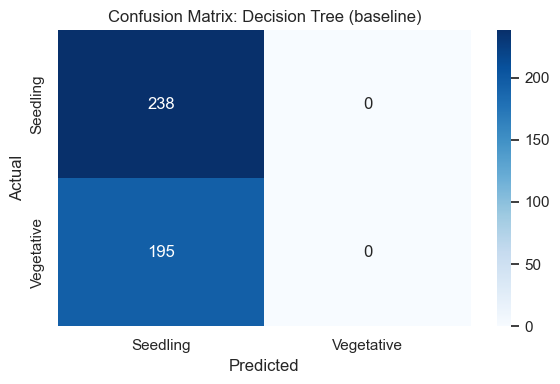


k-NN (baseline) | F1-macro=0.3169
              precision    recall  f1-score   support

    Seedling       0.46      1.00      0.63       238
  Vegetative       0.00      0.00      0.00       275

    accuracy                           0.46       513
   macro avg       0.23      0.50      0.32       513
weighted avg       0.22      0.46      0.29       513



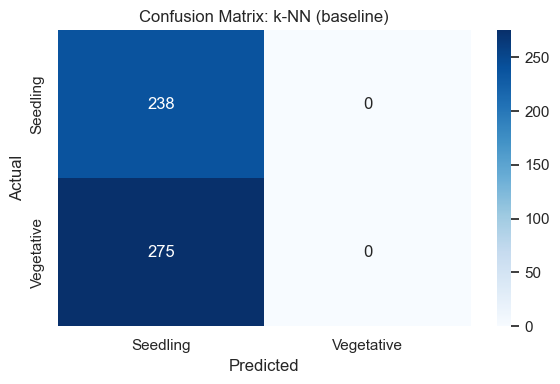


Random Forest (advanced) | F1-macro=0.3169
              precision    recall  f1-score   support

    Seedling       0.46      1.00      0.63       238
  Vegetative       0.00      0.00      0.00       275

    accuracy                           0.46       513
   macro avg       0.23      0.50      0.32       513
weighted avg       0.22      0.46      0.29       513



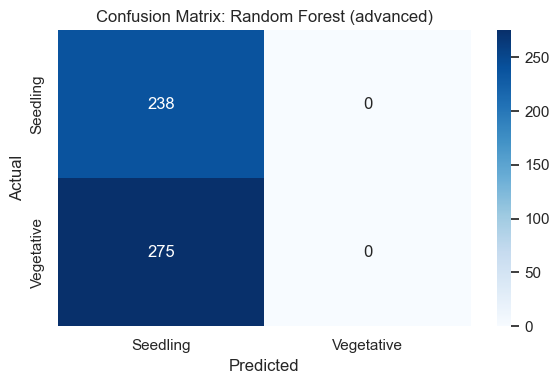

,model,f1_macro
1,k-NN (baseline),0.316911
2,Random Forest (advanced),0.316911
0,Decision Tree (baseline),0.236463


Best model by F1-macro: k-NN (baseline)


In [23]:
models = {
    # Shallow tree — fast interpretable baseline
    'Decision Tree (baseline)': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('model', DecisionTreeClassifier(max_depth=6, class_weight='balanced', random_state=42))
    ]),
    # Distance-based baseline — needs scaling, no class_weight support
    'k-NN (baseline)': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('model', KNeighborsClassifier(n_neighbors=7, weights='distance'))
    ]),
    # Ensemble — 400 trees with balanced class weights
    'Random Forest (advanced)': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('model', RandomForestClassifier(n_estimators=400, class_weight='balanced', random_state=42))
    ])
}

results = []
fitted_models = {}

for name, pipe in models.items():
    pipe.fit(X_train_bal, y_train_bal)
    pred = pipe.predict(X_test)
    f1   = f1_score(y_test, pred, average='macro', zero_division=0)
    results.append({'model': name, 'f1_macro': f1})

    # Store pipeline so SHAP or further inspection can access the fitted model
    fitted_models[name] = pipe

    print(f'\n{name} | F1-macro={f1:.4f}')
    print(classification_report(y_test, pred, zero_division=0))

    labels = sorted(y_test.unique())
    cm = confusion_matrix(y_test, pred, labels=labels)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels)
    plt.title(f'Confusion Matrix: {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

# Sort by F1 descending and report the winner
results_df = pd.DataFrame(results).sort_values('f1_macro', ascending=False)
display(results_df)
if not results_df.empty:
    print('Best model by F1-macro:', results_df.iloc[0]['model'])

## 4.5 SHAP Interpretability

**Goal:** Explain which features drive the best model's predictions using SHAP values, producing both a bar summary (global importance) and a beeswarm plot (per-class directional impact).

**Method:** `shap.TreeExplainer` is used for both XGBoost and Random Forest since both are tree-based, enabling exact (non-approximated) SHAP values. A sample of up to 300 test rows is used for speed. Feature names are renamed to human-readable labels before plotting, and a custom wrapper fixes SHAP's label truncation issue.

**Processes:**
- **Model selection:** best model is picked by highest `f1_macro` from `results_df`; falls back to Random Forest if the table is unavailable
- **Branch handling:** XGBoost stores `(model, imputer, label_encoder)` as a tuple while Random Forest stores a full sklearn Pipeline — each branch extracts components accordingly before passing to SHAP
- **Label fix:** SHAP truncates feature names to 8 characters; `shap_plot()` reconstructs full names via prefix matching and normalizes font sizes post-render
- **Plot layout:** figure width is forced to at least 16 inches and the legend is anchored outside the axes to prevent overlap

Best model: k-NN (baseline) — applying SHAP


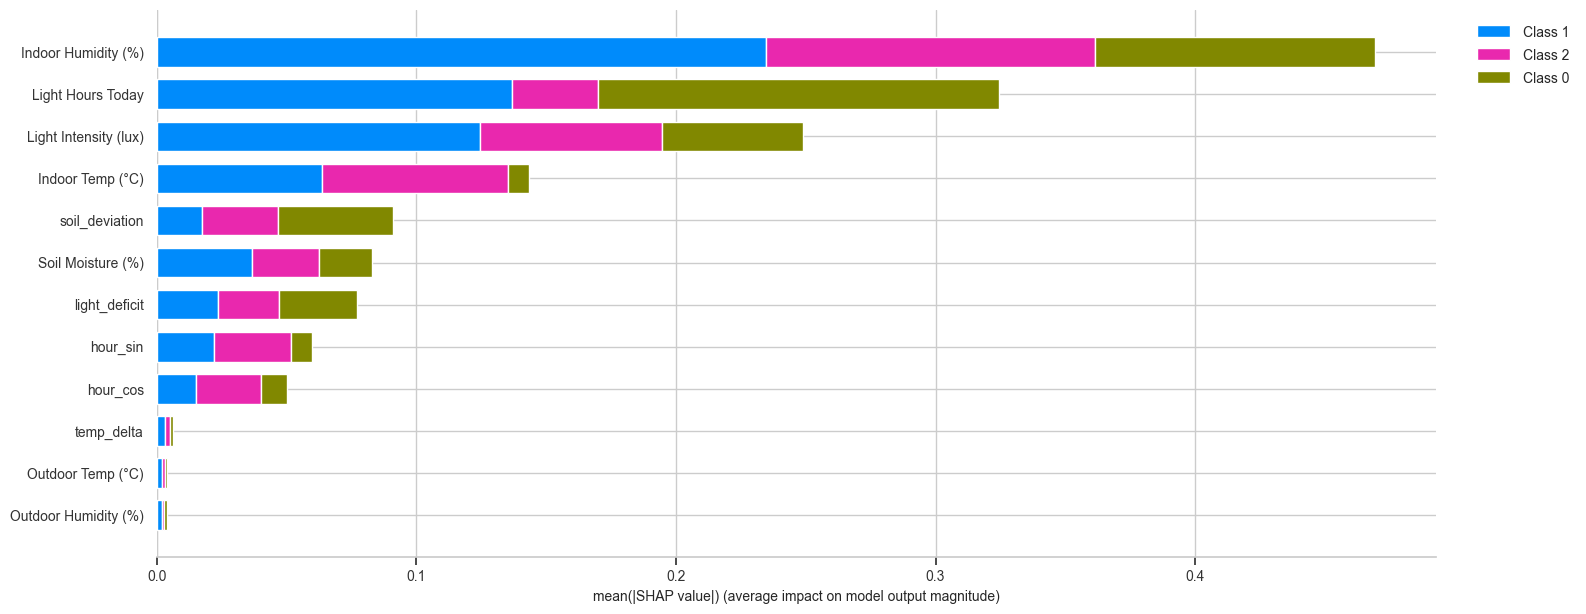

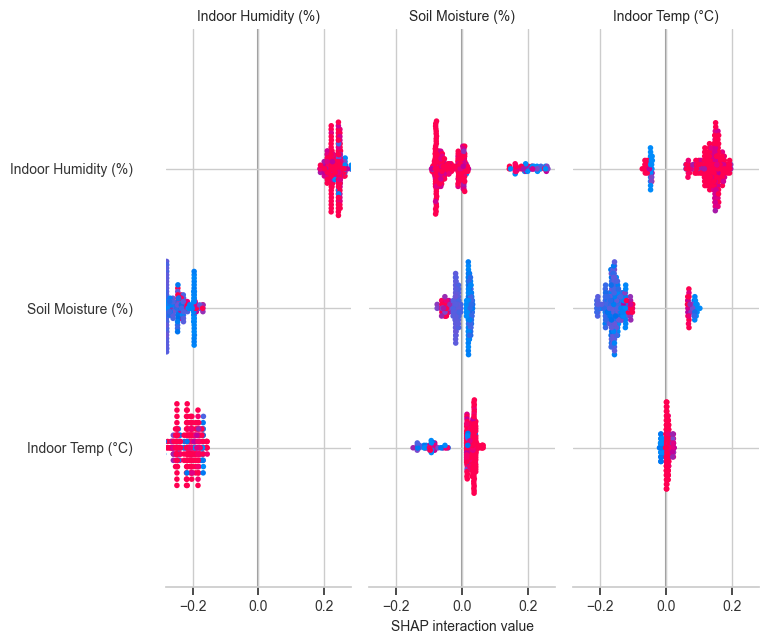

In [24]:
# Human-readable display names for each raw feature column used in SHAP plots
shap_rename = {
    col_temp_in:   "Indoor Temp (°C)",
    col_hum_in:    "Indoor Humidity (%)",
    col_soil:      "Soil Moisture (%)",
    col_light_lux: "Light Intensity (lux)",
    "light_hrs_today":  "Light Hours Today",
    "outdoor_temp":     "Outdoor Temp (°C)",
    "outdoor_humidity": "Outdoor Humidity (%)",
}

def shap_plot(shap_vals, X, plot_type="dot"):
    # SHAP truncates long feature names to 8 chars + "..."
    # Build a prefix map so we can restore full names after plotting
    all_labels = list(X.columns)
    prefix_map = {lbl[:8]: lbl for lbl in all_labels}

    shap.summary_plot(shap_vals, X, plot_type=plot_type, show=False)
    fig = plt.gcf()
    w, h = fig.get_size_inches()
    fig.set_size_inches(max(w, 16), h)  # Ensure figure is wide enough for long labels

    # Iterate all text objects in the figure:
    # - Replace any "..." truncated labels with their full name
    # - Normalize font size to 10pt for consistency
    for obj in fig.findobj(plt.Text):
        t = obj.get_text()
        if t.endswith("..."):
            prefix = t[:-3]
            for key, full in prefix_map.items():
                if full.startswith(prefix):
                    obj.set_text(full)
                    break
        if obj.get_text().strip():
            obj.set_fontsize(10)

    # Move legend outside the plot area so it doesn't overlap bars/dots
    for ax in fig.axes:
        legend = ax.get_legend()
        if legend:
            legend.set_bbox_to_anchor((1.02, 1))
            legend.set_loc("upper left")
    plt.tight_layout()
    plt.show()

# ── Select best model by F1-macro from results table ─────────────────────────
# Falls back to Random Forest if results_df is unavailable
if "results_df" in globals() and isinstance(results_df, pd.DataFrame) and not results_df.empty:
    best_name = results_df.sort_values("f1_macro", ascending=False).iloc[0]["model"]
else:
    best_name = "Random Forest (advanced)"
print(f"Best model: {best_name} — applying SHAP")

try:
    if best_name == "XGBoost (advanced)" and "XGBoost (advanced)" in fitted_models:
        # ── XGBoost branch ───────────────────────────────────────────────────
        # XGBoost was stored as a (model, imputer, label_encoder) tuple
        # because it was trained outside a sklearn Pipeline
        xgb_model, xgb_imp, xgb_le = fitted_models["XGBoost (advanced)"]
        shap_cols = list(X_train_bal.columns)

        # Apply the same imputer used during training before passing to SHAP
        X_test_shap = pd.DataFrame(
            xgb_imp.transform(X_test[shap_cols]),
            columns=shap_cols
        )

        # Sample up to 300 rows for speed; SHAP is O(n * features * trees)
        sample_n = min(300, len(X_test_shap))
        X_shap = X_test_shap.sample(n=sample_n, random_state=42) if sample_n > 0 else X_test_shap
        X_shap = X_shap.rename(columns=shap_rename)  # Apply display names

        explainer = shap.TreeExplainer(xgb_model)
        shap_vals = explainer.shap_values(X_shap)

        print("SHAP Bar Summary (mean |SHAP| across all classes):")
        shap_plot(shap_vals, X_shap, plot_type="bar")
        print("SHAP Beeswarm (class-level feature impact):")
        shap_plot(shap_vals, X_shap)

    elif "Random Forest (advanced)" in fitted_models:
        # ── Random Forest branch ──────────────────────────────────────────────
        # RF was stored as a full sklearn Pipeline, so extract steps by name
        rf_pipe    = fitted_models["Random Forest (advanced)"]
        rf_imputer = rf_pipe.named_steps["imputer"]
        rf_model   = rf_pipe.named_steps["model"]
        shap_cols  = list(X_train_bal.columns)

        # Impute before SHAP (pipeline imputer must be applied manually here
        # because SHAP needs the raw numpy array, not a pipeline object)
        X_test_shap = pd.DataFrame(
            rf_imputer.transform(X_test[shap_cols]),
            columns=shap_cols
        )

        sample_n = min(300, len(X_test_shap))
        X_shap = X_test_shap.sample(n=sample_n, random_state=42) if sample_n > 0 else X_test_shap
        X_shap = X_shap.rename(columns=shap_rename)

        explainer = shap.TreeExplainer(rf_model)
        shap_vals = explainer.shap_values(X_shap)
        shap_plot(shap_vals, X_shap, plot_type="bar")
        shap_plot(shap_vals, X_shap)

    else:
        print("No fitted tree model found. Run Sections 5a and 5.3 first.")

except Exception as e:
    print("SHAP error:", e)
    print("Tip: pip install shap")

## 5. Final Model Comparison

**Goal:** Rank all trained models by F1-macro and visually identify whether advanced models outperform baselines.

**Method:** `results_df` is sorted descending by `f1_macro` and displayed as both a color-coded bar chart and a full results table, with the top model printed explicitly.

**Processes:**
- **Color coding:** bars are colored red for baseline models and green for advanced models based on whether `'baseline'` appears in the model name
- **Guard clause:** the block checks that `results_df` exists and is non-empty before running, prompting the user to run earlier sections if not
- **Output:** bar chart, full sorted `final_df` table, and a printed summary of the best model and its F1 score

/var/folders/qj/jp8jlkfd4kl0tfjkyzqdpc600000gn/T/ipykernel_85451/759428677.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=final_df, x='model', y='f1_macro', palette='Set2')


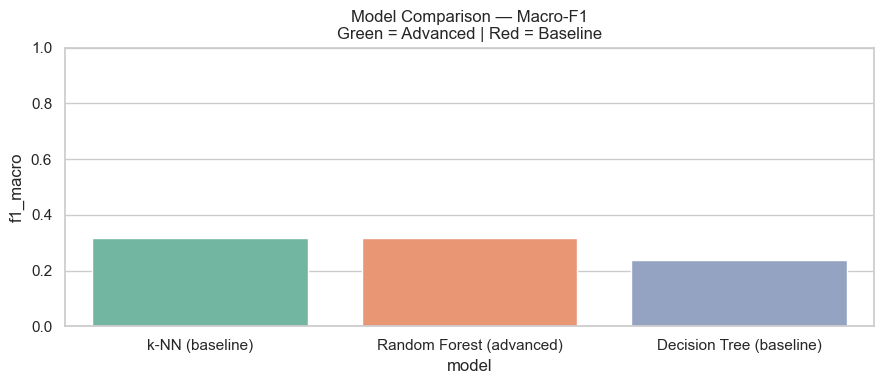

,model,f1_macro
0,k-NN (baseline),0.316911
1,Random Forest (advanced),0.316911
2,Decision Tree (baseline),0.236463


Best model: k-NN (baseline) (F1 = 0.3169)


In [25]:
# ── Sort all trained models by F1-macro descending for comparison ─────────────
if 'results_df' in globals() and isinstance(results_df, pd.DataFrame) and not results_df.empty:
    final_df = results_df.sort_values('f1_macro', ascending=False).reset_index(drop=True)

    # Color-code bars: red for baselines, green for advanced models
    colors = ['#F44336' if 'baseline' in m else '#4CAF50' for m in final_df['model']]

    plt.figure(figsize=(9, 4))
    sns.barplot(data=final_df, x='model', y='f1_macro', palette='Set2')
    plt.title('Model Comparison — Macro-F1\nGreen = Advanced | Red = Baseline')
    plt.ylim(0, 1)
    plt.xticks(rotation=0, ha='center')
    plt.tight_layout()
    plt.show()

    # Show full results table and print the top model
    display(final_df)
    print('Best model:', final_df.iloc[0]['model'],
          f"(F1 = {final_df.iloc[0]['f1_macro']:.4f})")

else:
    print('Run Sections 5.3 and 5a first to populate results.')

## 6. Health Score Regression (Optional)

**Goal:** Predict the continuous `health_score` target using three regression models and compare them by MAE and RMSE.

**Method:** Data is split chronologically by a fixed date cutoff (2026-04-15), falling back to the 80th-percentile timestamp if the cutoff falls outside the data range. Each model is wrapped in a unified impute → scale → predict pipeline and evaluated on the holdout period.

**Processes:**
- **Feature filtering:** columns are excluded if they are `None`, absent from the dataframe, or entirely NaN — preventing imputer failures on all-null inputs
- **Chronological split:** a time-based split is used instead of random shuffling to avoid leaking future sensor readings into training
- **Numerical safety:** `np.errstate` suppresses divide/overflow warnings from Linear Regression on edge-case data; `np.nan_to_num` replaces any resulting invalid predictions with median/min/max fallbacks
- **Unified pipeline:** all three models share the same impute → scale structure for fair comparison; results are collected into `reg_rows` and displayed sorted by MAE ascending

In [26]:
# ── Guard: only run if a valid health score column exists in features ──────────
if col_health and col_health in feat.columns:
    # Sort by timestamp for chronological train/test split
    reg_df = feat.dropna(subset=['ts']).sort_values('ts').copy()

    # Select feature columns that are defined and actually present in the dataframe
    X_cols_reg = [c for c in [
        col_temp_in, col_hum_in, col_soil, col_light_lux, col_light_hrs,
        col_temp_out_feat, col_hum_out_feat,
        'soil_deviation', 'temp_delta', 'light_deficit',
        'hour_sin', 'hour_cos'
    ] if c is not None and c in reg_df.columns]

    # Remove columns that are entirely NaN — imputer cannot handle all-null columns
    X_cols_reg = [c for c in X_cols_reg if reg_df[c].notna().any()]

    # Use a fixed date cutoff for the train/test split;
    # fall back to the 80th percentile timestamp if cutoff falls outside data range
    cutoff = pd.Timestamp('2026-04-15')
    split_ts = cutoff if reg_df['ts'].min() < cutoff < reg_df['ts'].max() else reg_df['ts'].quantile(0.8)
    train_mask = reg_df['ts'] < split_ts

    X_train_reg = reg_df.loc[train_mask, X_cols_reg]
    X_test_reg  = reg_df.loc[~train_mask, X_cols_reg]
    y_train_reg = reg_df.loc[train_mask, col_health]
    y_test_reg  = reg_df.loc[~train_mask, col_health]

    reg_models = {
        'Linear Regression':        LinearRegression(),
        'Decision Tree Regressor':  DecisionTreeRegressor(max_depth=6, random_state=42),
        'k-NN Regressor':           KNeighborsRegressor(n_neighbors=7),
    }

    reg_rows = []
    for name, model in reg_models.items():
        # All models share the same pipeline: impute → scale → fit
        # Scaling is included even for tree models to keep the pipeline uniform
        pipe = Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler',  StandardScaler()),
            ('model',   model)
        ])
        pipe.fit(X_train_reg, y_train_reg)

        # Suppress divide/overflow warnings that can occur with Linear Regression
        # on edge-case data; replace any resulting NaN/inf predictions with safe fallbacks
        with np.errstate(divide='ignore', over='ignore', invalid='ignore'):
            pred = pipe.predict(X_test_reg)
        pred = np.nan_to_num(pred,
                             nan=y_train_reg.median(),
                             posinf=y_train_reg.max(),
                             neginf=y_train_reg.min())

        mae  = mean_absolute_error(y_test_reg, pred)
        rmse = np.sqrt(mean_squared_error(y_test_reg, pred))
        reg_rows.append({'model': name, 'mae': mae, 'rmse': rmse})
        print(f'{name}: MAE={mae:.4f}, RMSE={rmse:.4f}')

    # Display results sorted by MAE ascending (lower is better)
    display(pd.DataFrame(reg_rows).sort_values('mae'))

else:
    print('health_score not found; skip regression task.')

Linear Regression: MAE=8.8663, RMSE=10.6318
Decision Tree Regressor: MAE=9.0560, RMSE=20.5682
k-NN Regressor: MAE=7.0292, RMSE=12.3186


,model,mae,rmse
2,k-NN Regressor,7.029183,12.318584
0,Linear Regression,8.866314,10.631840
1,Decision Tree Regressor,9.055969,20.568226


## 7) References
- Scikit-learn docs: Decision Tree, k-NN, Random Forest, IsolationForest, TimeSeriesSplit
- XGBoost docs: https://xgboost.readthedocs.io
- imbalanced-learn docs (SMOTE): https://imbalanced-learn.org
- SHAP docs: https://shap.readthedocs.io
- Open-Meteo API docs: https://open-meteo.com
- Liu, F. T., Ting, K. M., & Zhou, Z. H. (2008). *Isolation Forest*. ICDM 2008.
- Chen, T., & Guestrin, C. (2016). *XGBoost: A Scalable Tree Boosting System*. KDD 2016.
- Lundberg, S. M., & Lee, S.-I. (2017). *A Unified Approach to Interpreting Model Predictions*. NeurIPS 2017.
